In [1]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


In [29]:
#protein = 'ChiZ1-64'
protein = 'KRS1-72'

all_IDs = []
for system in systems:
    if protein in system['SYSTEM']:
        all_IDs.append(system['ID'])

print('Found IDs: ', all_IDs)

Found IDs:  [1, 5, 8, 9, 13, 14, 15, 17, 21, 23, 25, 26, 27, 30, 31, 37, 38, 39, 40, 45, 46, 48, 49, 50]


In [41]:
SRCS_data = {}

for system in systems:
    ID = system['ID']
    if ID in all_IDs:
        data_folder = '../../Data/Simulations/' + system['path']
        trj = data_folder + system['TRJ'][0][0]
        gro = data_folder + 'protein_centered.gro'
        #file_paths.append((ID,trj,gro))
        spin_relaxation_file_rmsd = data_folder + 'spin_relaxation_rmsd.yaml'
        chemical_shift_file_rmsd = data_folder + 'chemical_shift_rmsd.yaml'
        with open(spin_relaxation_file_rmsd, "r") as f:
            spin_relaxation_rmsd = yaml.safe_load(f)
        with open(chemical_shift_file_rmsd, "r") as f:
            chemical_shift_rmsd = yaml.safe_load(f)
        #print(chemical_shift_rmsd)
        sr_total_rmsd = spin_relaxation_rmsd['R1'] + spin_relaxation_rmsd['R2'] + spin_relaxation_rmsd['hetNOE']
        cs_total_rmsd = chemical_shift_rmsd['C'] + chemical_shift_rmsd['CA'] + chemical_shift_rmsd['CB']
        replica, ff = parse_trj_info(trj)
        print(ID, replica, ff, spin_relaxation_rmsd['R1'], spin_relaxation_rmsd['R2'], spin_relaxation_rmsd['hetNOE'])
        print(ID, replica, ff, chemical_shift_rmsd['C'], chemical_shift_rmsd['CA'],chemical_shift_rmsd['CB'])
        print()
        SRCS_data[ID] = {
            'trj': trj,
            'spin_relaxation': sr_total_rmsd,
            'chemical_shift': cs_total_rmsd
        }


2 replica_03 AMBER99SBWS 0.3863450732151246 1.7238410771925305 0.3935089616472289
2 replica_03 AMBER99SBWS 0.38404483774046594 0.4506732743470705 0.403023963535113

3 replica_03 AMBER03WS 0.482515684835688 1.9259601654973373 0.5584212689510004
3 replica_03 AMBER03WS 0.49879331118054987 0.5531942268311758 0.37725922612933116

4 replica_04 AMBER99SBWS 0.3597874956866384 1.6735987445101517 0.3145509781668761
4 replica_04 AMBER99SBWS 0.41986902491709344 0.4744230711225341 0.4188753414248197

6 replica_05 AMBER03WS 0.5315781255248466 1.973671512594249 0.6454673053074513
6 replica_05 AMBER03WS 0.4714460606823677 0.5516234979298491 0.38721360356263534

7 replica_03 CHARMM36M 0.22122395944613407 1.0258290628203104 0.320623511046896
7 replica_03 CHARMM36M 0.555220192249192 0.5912078871330074 0.7375497095972612

10 replica_04 AMBER03WS 0.4567473525800196 1.8907263950976883 0.4905579639013628
10 replica_04 AMBER03WS 0.4559363485420128 0.5127767396286739 0.3865336228004478

11 replica_02 AMBER99SB

In [11]:
import os

def parse_trj_info(trj_path):
    """Extract replica name and force field from a trajectory file path."""
    fname = os.path.basename(trj_path)  # e.g. replica_03_AMBER03WS_md_1500ns.xtc
    parts = fname.split("_")
    replica = parts[0] + "_" + parts[1]   # "replica_03"
    forcefield = parts[2]                 # "AMBER03WS"
    return replica, forcefield


In [33]:
# Rank by spin_relaxation
rank_spin = sorted(data.items(), key=lambda x: x[1]["spin_relaxation"])

# Rank by chemical_shift
rank_shift = sorted(data.items(), key=lambda x: x[1]["chemical_shift"])

print("Ranking by spin_relaxation (min → max):")
for idx, (k, v) in enumerate(rank_spin, 1):
    replica, ff = parse_trj_info(v["trj"])
    print(f"{idx:2d}. ID {k} | {replica} | {ff} "
          f"-> spin_relaxation={v['spin_relaxation']:.3f}")

print("\nRanking by chemical_shift (min → max):")
for idx, (k, v) in enumerate(rank_shift, 1):
    replica, ff = parse_trj_info(v["trj"])
    print(f"{idx:2d}. ID {k} | {replica} | {ff} "
          f"-> chemical_shift={v['chemical_shift']:.3f}")


Ranking by spin_relaxation (min → max):
 1. ID 12 | replica_05 | CHARMM36M -> spin_relaxation=1.514
 2. ID 7 | replica_03 | CHARMM36M -> spin_relaxation=1.568
 3. ID 22 | replica_05 | AMBER99SB-DISP -> spin_relaxation=1.600
 4. ID 36 | replica_04 | CHARMM36M -> spin_relaxation=1.615
 5. ID 28 | replica_01 | CHARMM36M -> spin_relaxation=1.657
 6. ID 24 | replica_01 | AMBER99SB-DISP -> spin_relaxation=1.702
 7. ID 43 | replica_02 | DESAMBER -> spin_relaxation=1.704
 8. ID 41 | replica_04 | AMBER99SB-DISP -> spin_relaxation=1.725
 9. ID 18 | replica_02 | CHARMM36M -> spin_relaxation=1.806
10. ID 32 | replica_05 | DESAMBER -> spin_relaxation=1.927
11. ID 20 | replica_03 | DESAMBER -> spin_relaxation=1.971
12. ID 33 | replica_04 | DESAMBER -> spin_relaxation=2.004
13. ID 35 | replica_01 | AMBER99SBWS -> spin_relaxation=2.216
14. ID 47 | replica_02 | AMBER99SBWS -> spin_relaxation=2.273
15. ID 16 | replica_01 | DESAMBER -> spin_relaxation=2.322
16. ID 4 | replica_04 | AMBER99SBWS -> spin_rel

In [31]:
print(SRCS_data)


data = SRCS_data

# Rank by spin_relaxation (ascending → min first)
rank_spin = sorted(data.items(), key=lambda x: x[1]["spin_relaxation"])

# Rank by chemical_shift (ascending → min first)
rank_shift = sorted(data.items(), key=lambda x: x[1]["chemical_shift"])

print("Ranking by spin_relaxation (min → max):")
for idx, (k, v) in enumerate(rank_spin, 1):
    print(f"{idx:2d}. ID {k} -> {v['spin_relaxation']:.3f}")

print("\nRanking by chemical_shift (min → max):")
for idx, (k, v) in enumerate(rank_shift, 1):
    print(f"{idx:2d}. ID {k} -> {v['chemical_shift']:.3f}")


{2: {'trj': '../../Data/Simulations/cdf/798/cdf7987102d6473c8ad0ab8a4f7c384b16b4cb5b/bab80edfd37192c8d2df12c5865f2c658d21a7d1/replica_03_AMBER99SBWS_md_1500ns.xtc', 'spin_relaxation': 2.503695112054884, 'chemical_shift': 1.2377420756226494}, 3: {'trj': '../../Data/Simulations/082/ab4/082ab4aadd4dcb08f1f8b5c27c7f7c4e0c592c55/b6b68bfc7e719eafc21ce452ff6f44d214769ce1/replica_03_AMBER03WS_md_1500ns.xtc', 'spin_relaxation': 2.9668971192840257, 'chemical_shift': 1.4292467641410567}, 4: {'trj': '../../Data/Simulations/ead/ea4/eadea42c0c2e4be95ab0fdddf1bb8cb8f37f88bc/2147ba4d757f0218ab957ac602c5289659a36a26/replica_04_AMBER99SBWS_md_1500ns.xtc', 'spin_relaxation': 2.347937218363666, 'chemical_shift': 1.3131674374644473}, 6: {'trj': '../../Data/Simulations/a99/493/a99493b9f1af9649db5f09eae8a8d247316e6725/69cb47a60cbe364fef7e1596943b95f88c90e747/replica_05_AMBER03WS_md_1500ns.xtc', 'spin_relaxation': 3.1507169434265467, 'chemical_shift': 1.4102831621748524}, 7: {'trj': '../../Data/Simulations/53

In [23]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def calculate_backbone_correlations_dist(gro_file, xtc_file, output_file):

    outfile_png = output_file
    outfile_csv = output_file.replace(".png", ".csv")
    outfile_dist = output_file.replace(".png", "_dist.csv")

    u = mda.Universe(gro_file, xtc_file)
    CAatoms = u.select_atoms("name CA")

    num_atoms = len(CAatoms)
    num_vectors = num_atoms - 1
    vec = np.zeros((num_vectors, 3))
    matrix = np.zeros((num_vectors, num_vectors))

    # Store all frame values for distributions
    all_frames = []

    for frame in u.trajectory:
        for i in range(num_vectors):
            vec[i] = CAatoms[i + 1].position - CAatoms[i].position
            vec[i] /= np.linalg.norm(vec[i])
        corr_matrix = np.dot(vec, vec.T)
        matrix += corr_matrix

        # flatten upper triangle for storage (or full matrix if you prefer)
        all_frames.append(corr_matrix.flatten())

    # Average correlation matrix
    matrix /= len(u.trajectory)

    # Save average matrix
    np.savetxt(outfile_csv, matrix, delimiter=",")

    # Save full distribution as DataFrame: rows=frames, cols=matrix elements
    df = pd.DataFrame(all_frames)
    df.to_csv(outfile_dist, index=False)

    # Plot average heatmap
    plt.figure(figsize=(6, 5))
    color_map = plt.imshow(matrix, vmin=-1, vmax=1, cmap="seismic", origin="lower")

    cbar = plt.colorbar(color_map)
    cbar.ax.tick_params(labelsize=16)

    plt.tick_params(axis="both", which="major", labelsize=12)
    plt.xlabel(r"C$_{\alpha}$ Pair Index", fontsize=16)
    plt.ylabel(r"C$_{\alpha}$ Pair Index", fontsize=16)

    plt.tight_layout()
    plt.savefig(outfile_png, dpi=600)
    plt.close("all")


In [32]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def calculate_backbone_correlation_distributions(gro_file, xtc_file, output_file, bins=50):

    outfile_png = output_file
    outfile_csv = output_file.replace(".png", ".csv")
    outfile_dist = output_file.replace(".png", "_dist.csv")

    u = mda.Universe(gro_file, xtc_file)
    CAatoms = u.select_atoms("name CA")

    num_atoms = len(CAatoms)
    num_vectors = num_atoms - 1
    vec = np.zeros((num_vectors, 3))
    avg_matrix = np.zeros((num_vectors, num_vectors))

    # Histogram setup
    bin_edges = np.linspace(-1, 1, bins + 1)
    histograms = np.zeros((num_vectors, num_vectors, bins), dtype=int)

    for ts in u.trajectory:
        # Build backbone vectors
        for i in range(num_vectors):
            vec[i] = CAatoms[i + 1].position - CAatoms[i].position
            vec[i] /= np.linalg.norm(vec[i])
        corr_matrix = np.dot(vec, vec.T)

        avg_matrix += corr_matrix

        # Update histograms
        for i in range(num_vectors):
            for j in range(num_vectors):
                val = corr_matrix[i, j]
                bin_idx = np.searchsorted(bin_edges, val, side="right") - 1
                if 0 <= bin_idx < bins:
                    histograms[i, j, bin_idx] += 1

    # Normalize average matrix
    avg_matrix /= len(u.trajectory)

    # Save average matrix
    np.savetxt(outfile_csv, avg_matrix, delimiter=",")

    # Save histograms (flattened table for easier use later)
    col_names = [f"pair_{i}_{j}" for i in range(num_vectors) for j in range(num_vectors)]
    df_hist = pd.DataFrame(
        histograms.reshape(num_vectors * num_vectors, bins).T,
        columns=col_names
    )
    df_hist["bin_left"] = bin_edges[:-1]
    df_hist["bin_right"] = bin_edges[1:]
    df_hist.to_csv(outfile_dist, index=False)

    # Plot average matrix
    #plt.figure(figsize=(6, 5))
    #im = plt.imshow(avg_matrix, vmin=-1, vmax=1, cmap="seismic", origin="lower")
    #cbar = plt.colorbar(im)
    #cbar.ax.tick_params(labelsize=16)
    #plt.tick_params(axis="both", which="major", labelsize=12)
    #plt.xlabel(r"C$_{\alpha}$ Pair Index", fontsize=16)
    #plt.ylabel(r"C$_{\alpha}$ Pair Index", fontsize=16)
    #plt.tight_layout()
    #plt.savefig(outfile_png, dpi=600)
    #plt.close()


In [33]:
output_file = 'tst.png'

for system in systems:
    #for i in system:
    #    print(i)
    #print(system['TOP'])
    if system['ID'] > 1:
        continue
    xtc_file = '../../Data/Simulations/' + system['path'] +  system['TRJ'][0][0]
    gro_file = '../../Data/Simulations/' + system['path'] +  'protein_centered.gro'
    calculate_backbone_correlation_distributions(gro_file, xtc_file, output_file)

In [34]:
def plot_pair_distribution(dist_file, pair_name):
    """
    Plot the correlation distribution for a given pair from the saved dist.csv file.
    
    Parameters
    ----------
    dist_file : str
        Path to the *_dist.csv file created by calculate_backbone_correlation_distributions
    pair_name : str
        Column name for the pair (e.g. "pair_0_1")
    """
    # Load distribution file
    df = pd.read_csv(dist_file)

    # Extract bin edges
    bin_left = df["bin_left"].values
    bin_right = df["bin_right"].values
    bin_centers = 0.5 * (bin_left + bin_right)

    # Extract histogram counts for the chosen pair
    if pair_name not in df.columns:
        raise ValueError(f"Pair {pair_name} not found. Available columns: {list(df.columns[:10])}...")
    
    counts = df[pair_name].values
    probabilities = counts / counts.sum()  # normalize to probability

    # Plot distribution
    plt.bar(bin_centers, probabilities, width=bin_right - bin_left, align="center", alpha=0.7)
    plt.xlabel("Correlation value")
    plt.ylabel("Probability")
    plt.title(f"Distribution of correlations for {pair_name}")
    plt.tight_layout()
    plt.show()

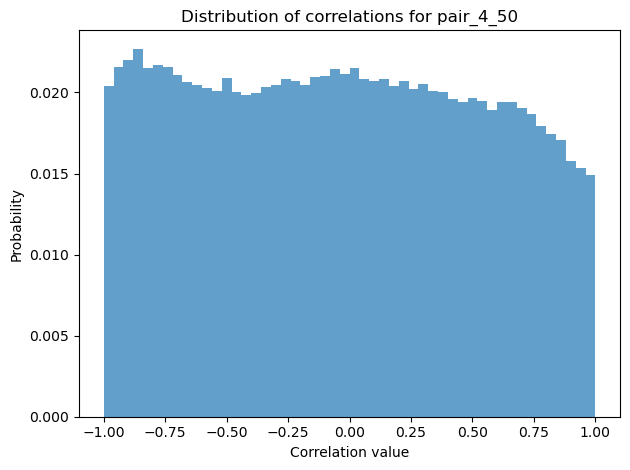

In [36]:
plot_pair_distribution("tst_dist.csv", "pair_4_50")

In [25]:
import pandas as pd

# Load the file
df = pd.read_csv("tst_dist.csv")   # replace with your filename

# See the shape and first few rows
print(df.shape)   # (n_frames, n_pairs)
print(df.head())

# List available columns (pairs)
print(df.columns[:10])  # show first 10 pair names

# Example: extract the correlation distribution for pair (0,1)
pair_01 = df["pair_0_1"]
print(pair_01.describe())   # summary stats
print(pair_01.head())

# Plot its time evolution
import matplotlib.pyplot as plt

plt.plot(pair_01)
plt.xlabel("Frame")
plt.ylabel("Correlation value")
plt.title("Correlation over time for pair_0_1")
plt.show()

# Plot histogram (distribution) of the same pair
plt.hist(pair_01, bins=50, density=True)
plt.xlabel("Correlation value")
plt.ylabel("Frequency")
plt.title("Distribution of correlations for pair_0_1")
plt.show()


(67089, 5041)
     0         1         2         3         4         5         6         7  \
0  1.0 -0.811286 -0.261081 -0.874292  0.009808 -0.586738 -0.104383 -0.864595   
1  1.0 -0.778553  0.044932 -0.781447 -0.225658 -0.594306 -0.200026 -0.939610   
2  1.0 -0.850067 -0.186218 -0.983678 -0.112817 -0.660680 -0.079620 -0.922981   
3  1.0 -0.786029  0.005530 -0.969439 -0.346962 -0.796272 -0.218732 -0.918550   
4  1.0 -0.870145 -0.042470 -0.903904 -0.249400 -0.773805 -0.223737 -0.948370   

          8         9  ...      5031      5032      5033      5034      5035  \
0 -0.010903 -0.901839  ...  0.085459 -0.182353  0.016345 -0.111572  0.154206   
1 -0.090546 -0.917487  ...  0.228885 -0.112067  0.527226 -0.037811 -0.059464   
2 -0.090865 -0.906996  ...  0.539892 -0.297787  0.530919 -0.136974 -0.160762   
3 -0.200516 -0.849835  ...  0.606432 -0.054559  0.386974 -0.200446 -0.362781   
4 -0.134271 -0.985884  ...  0.438347 -0.035518  0.217273 -0.300611 -0.106771   

       5036      5037   

KeyError: 'pair_0_1'

(67089, 5041)
     0         1         2         3         4         5         6         7  \
0  1.0 -0.811286 -0.261081 -0.874292  0.009808 -0.586738 -0.104383 -0.864595   
1  1.0 -0.778553  0.044932 -0.781447 -0.225658 -0.594306 -0.200026 -0.939610   
2  1.0 -0.850067 -0.186218 -0.983678 -0.112817 -0.660680 -0.079620 -0.922981   
3  1.0 -0.786029  0.005530 -0.969439 -0.346962 -0.796272 -0.218732 -0.918550   
4  1.0 -0.870145 -0.042470 -0.903904 -0.249400 -0.773805 -0.223737 -0.948370   

          8         9  ...      5031      5032      5033      5034      5035  \
0 -0.010903 -0.901839  ...  0.085459 -0.182353  0.016345 -0.111572  0.154206   
1 -0.090546 -0.917487  ...  0.228885 -0.112067  0.527226 -0.037811 -0.059464   
2 -0.090865 -0.906996  ...  0.539892 -0.297787  0.530919 -0.136974 -0.160762   
3 -0.200516 -0.849835  ...  0.606432 -0.054559  0.386974 -0.200446 -0.362781   
4 -0.134271 -0.985884  ...  0.438347 -0.035518  0.217273 -0.300611 -0.106771   

       5036      5037   

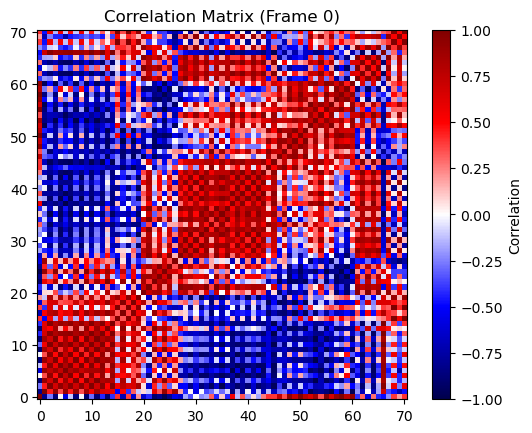

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


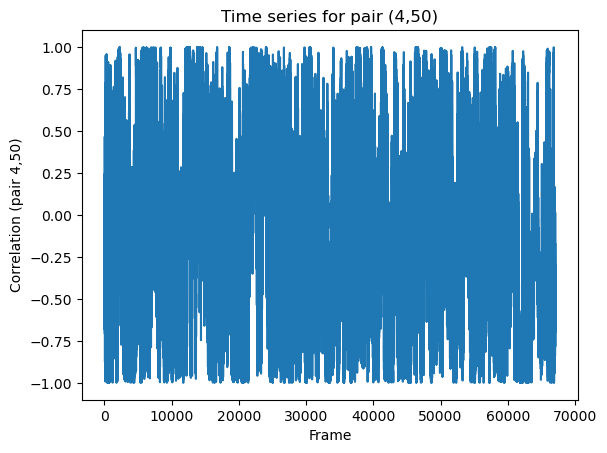

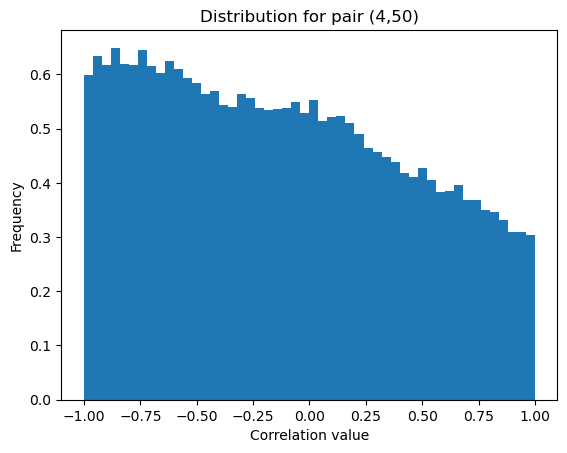

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dist file
df = pd.read_csv("tst_dist.csv")   # replace with your filename
print(df.shape)   # (n_frames, n_pairs)
print(df.head())

# Each row = one frame
# Each row is a flattened correlation matrix (square)
n_pairs = df.shape[1]
n_vectors = int(np.sqrt(n_pairs))  # since matrix was flattened

print(f"Matrix size per frame: {n_vectors} x {n_vectors}")

# Example: reconstruct correlation matrix for the first frame
frame0 = df.iloc[0].to_numpy().reshape(n_vectors, n_vectors)
print(frame0)

plt.imshow(frame0, vmin=-1, vmax=1, cmap="seismic", origin="lower")
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix (Frame 0)")
plt.show()

# Example: extract correlation time series for element (i,j)
i, j = 4, 50
pair_time_series = df.apply(lambda row: row[i*n_vectors + j], axis=1)

# Plot time evolution
plt.plot(pair_time_series)
plt.xlabel("Frame")
plt.ylabel(f"Correlation (pair {i},{j})")
plt.title(f"Time series for pair ({i},{j})")
plt.show()

# Plot distribution (histogram) of that pair
plt.hist(pair_time_series, bins=50, density=True)
plt.xlabel("Correlation value")
plt.ylabel("Frequency")
plt.title(f"Distribution for pair ({i},{j})")
plt.show()


In [52]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

def calculate_js_matrix_from_traj(gro1, xtc1, gro2, xtc2,
                                  output_csv, output_png=None,
                                  bins=50):
    """
    Calculate Jensen-Shannon divergence matrix between two trajectories
    directly from GRO+XTC files.

    Parameters
    ----------
    gro1, xtc1 : str
        Structure and trajectory for first simulation
    gro2, xtc2 : str
        Structure and trajectory for second simulation
    output_csv : str
        Where to save JS divergence matrix (CSV)
    output_png : str, optional
        Where to save heatmap (PNG)
    bins : int
        Number of histogram bins for distributions
    """
    # Load universes
    u1 = mda.Universe(gro1, xtc1)
    u2 = mda.Universe(gro2, xtc2)

    CA1 = u1.select_atoms("name CA")
    CA2 = u2.select_atoms("name CA")

    print(len(CA1),len(CA2))
    num_atoms = len(CA1)
    num_vectors = num_atoms - 1
    vec1 = np.zeros((num_vectors, 3))
    vec2 = np.zeros((num_vectors, 3))

    # Histograms for both trajectories
    bin_edges = np.linspace(-1, 1, bins + 1)
    hist1 = np.zeros((num_vectors, num_vectors, bins), dtype=int)
    hist2 = np.zeros((num_vectors, num_vectors, bins), dtype=int)

    # Process first trajectory
    for ts in u1.trajectory:
        #print(ts)
        for i in range(num_vectors):
            vec1[i] = CA1[i + 1].position - CA1[i].position
            vec1[i] /= np.linalg.norm(vec1[i])
        corr_matrix = np.dot(vec1, vec1.T)
        for i in range(num_vectors):
            for j in range(num_vectors):
                val = corr_matrix[i, j]
                bin_idx = np.searchsorted(bin_edges, val, side="right") - 1
                if 0 <= bin_idx < bins:
                    hist1[i, j, bin_idx] += 1

    print(hist1)
    # Process second trajectory
    for ts in u2.trajectory:
        for i in range(num_vectors):
            vec2[i] = CA2[i + 1].position - CA2[i].position
            vec2[i] /= np.linalg.norm(vec2[i])
        corr_matrix = np.dot(vec2, vec2.T)
        for i in range(num_vectors):
            for j in range(num_vectors):
                val = corr_matrix[i, j]
                bin_idx = np.searchsorted(bin_edges, val, side="right") - 1
                if 0 <= bin_idx < bins:
                    hist2[i, j, bin_idx] += 1

    print(hist2)
    
    # Compute JS divergence for each pair
    js_matrix = np.zeros((num_vectors, num_vectors))
    for i in range(num_vectors):
        for j in range(num_vectors):
            p = hist1[i, j].astype(float)
            q = hist2[i, j].astype(float)
            if p.sum() > 0:
                p /= p.sum()
            if q.sum() > 0:
                q /= q.sum()
            if p.sum() > 0 and q.sum() > 0:
                js_matrix[i, j] = jensenshannon(p, q, base=2) ** 2
            else:
                js_matrix[i, j] = np.nan  # undefined if both distributions empty

    # Save to CSV
    np.savetxt(output_csv, js_matrix, delimiter=",")

    # Optional: plot heatmap
    if output_png:
        plt.figure(figsize=(6, 5))
        im = plt.imshow(js_matrix, cmap="viridis", origin="lower")
        cbar = plt.colorbar(im)
        cbar.ax.tick_params(labelsize=12)
        plt.xlabel("C$_{\\alpha}$ Pair Index", fontsize=14)
        plt.ylabel("C$_{\\alpha}$ Pair Index", fontsize=14)
        plt.title("Jensen-Shannon Divergence Matrix", fontsize=14)
        plt.tight_layout()
        plt.savefig(output_png, dpi=600)
        plt.close()

    return js_matrix


# Example usage:
# js_matrix = calculate_js_matrix_from_traj(
#     "traj1.gro", "traj1.xtc",
#     "traj2.gro", "traj2.xtc",
#     "js_matrix.csv", "js_matrix.png"
# )


In [53]:
output_file = 'tst.png'

for system in systems:
    #for i in system:
    #    print(i)
    #print(system['TOP'])
    if system['ID'] == 2:
        xtc_file1 = '../../Data/Simulations/' + system['path'] +  system['TRJ'][0][0]
        gro_file1 = '../../Data/Simulations/' + system['path'] +  'protein_centered.gro'
    elif system['ID'] == 3:
        xtc_file2 = '../../Data/Simulations/' + system['path'] +  system['TRJ'][0][0]
        gro_file2 = '../../Data/Simulations/' + system['path'] +  'protein_centered.gro'
    else:
        continue
    
js_matrix = calculate_js_matrix_from_traj(
    gro_file1, xtc_file1,
    gro_file2, xtc_file2,
    "js_matrix.csv", "js_matrix.png"
    ) 

67 67
[[[    0     0     0 ...     0     0 43865]
  [ 2441   602   702 ...   157     9     2]
  [ 1478   805   765 ...  8056  8635  9596]
  ...
  [ 3555  3243  3122 ...  2830  2805  2998]
  [ 3153  2907  3103 ...  2934  2842  3262]
  [ 3052  2968  2973 ...  2842  2924  2985]]

 [[ 2441   602   702 ...   157     9     2]
  [    0     0     0 ...     0     0 43638]
  [ 2821   639   689 ...   284    25     5]
  ...
  [ 3148  3090  2988 ...  3083  3024  3058]
  [ 3169  2993  3063 ...  2832  2936  3038]
  [ 3081  2902  2928 ...  2985  2948  3091]]

 [[ 1478   805   765 ...  8056  8635  9596]
  [ 2821   639   689 ...   284    25     5]
  [    0     0     0 ...     0     0 43830]
  ...
  [ 3327  3224  3217 ...  2867  2757  2768]
  [ 3228  3335  3248 ...  2983  3017  3026]
  [ 3183  3064  3017 ...  3071  3047  3145]]

 ...

 [[ 3555  3243  3122 ...  2830  2805  2998]
  [ 3148  3090  2988 ...  3083  3024  3058]
  [ 3327  3224  3217 ...  2867  2757  2768]
  ...
  [    0     0     0 ...     0    

In [51]:
xtc_file1


'../../Data/Simulations/cdf/798/cdf7987102d6473c8ad0ab8a4f7c384b16b4cb5b/bab80edfd37192c8d2df12c5865f2c658d21a7d1/replica_03_AMBER99SBWS_md_1500ns.xtc'

In [58]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon

def calculate_js_matrix(dist_file1, dist_file2, output_csv, output_png=None):
    """
    Calculate the Jensen-Shannon divergence matrix between distributions
    stored in two *_dist.csv files (created by calculate_backbone_correlation_distributions).

    Parameters
    ----------
    dist_file1 : str
        Path to first *_dist.csv file
    dist_file2 : str
        Path to second *_dist.csv file
    output_csv : str
        Path to save JS divergence matrix as CSV
    output_png : str, optional
        Path to save heatmap as PNG (if given)

    Returns
    -------
    js_matrix : np.ndarray
        Square matrix of JS divergence values
    js_mean : float
        Average JS divergence across all pairs
    """
    # Load both distribution files
    df1 = pd.read_csv(dist_file1)
    df2 = pd.read_csv(dist_file2)

    # Ensure same bins
    if not np.allclose(df1["bin_left"], df2["bin_left"]):
        raise ValueError("Bin edges in the two files do not match.")
    
    # Drop bin edges
    df1 = df1.drop(columns=["bin_left", "bin_right"])
    df2 = df2.drop(columns=["bin_left", "bin_right"])

    # Ensure same columns
    if list(df1.columns) != list(df2.columns):
        raise ValueError("Pair columns do not match between files.")
    
    col_names = df1.columns
    num_pairs = len(col_names)
    n_vectors = int(np.sqrt(num_pairs))

    # Calculate JS divergence per pair
    js_values = []
    for col in col_names:
        p = df1[col].values.astype(float)
        q = df2[col].values.astype(float)

        # Normalize to probability distributions
        p = p / p.sum() if p.sum() > 0 else np.zeros_like(p)
        q = q / q.sum() if q.sum() > 0 else np.zeros_like(q)

        # JS divergence
        js = jensenshannon(p, q, base=2) ** 2  # scipy returns sqrt(JS), so square it
        js_values.append(js)

    # Reshape into square matrix
    js_matrix = np.array(js_values).reshape(n_vectors, n_vectors)

    # Compute average divergence
    js_mean = np.nanmean(js_matrix)

    # Save CSV
    np.savetxt(output_csv, js_matrix, delimiter=",")

    # Optional: plot heatmap
    if output_png is not None:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6,5))
        im = plt.imshow(js_matrix, cmap="viridis", origin="lower")
        cbar = plt.colorbar(im)
        cbar.ax.tick_params(labelsize=12)
        plt.xlabel("C$_{\\alpha}$ Pair Index", fontsize=14)
        plt.ylabel("C$_{\\alpha}$ Pair Index", fontsize=14)
        plt.title("Jensen-Shannon Divergence Matrix", fontsize=14)
        plt.tight_layout()
        plt.savefig(output_png, dpi=600)
        plt.close()

    return js_matrix, js_mean


# Example usage:
# js_matrix, js_mean = calculate_js_matrix("traj1_dist.csv", "traj2_dist.csv",
#                                          "js_matrix.csv", "js_matrix.png")
# print("Average JS divergence:", js_mean)


In [59]:
dist1 = "../../Data/Simulations/cdf/798/cdf7987102d6473c8ad0ab8a4f7c384b16b4cb5b/bab80edfd37192c8d2df12c5865f2c658d21a7d1/backbone_correlation_distribution.csv"
dist2 = "../../Data/Simulations/082/ab4/082ab4aadd4dcb08f1f8b5c27c7f7c4e0c592c55/b6b68bfc7e719eafc21ce452ff6f44d214769ce1/backbone_correlation_distribution.csv"
js_matrix, js_mean = calculate_js_matrix(dist1,dist2,"js_matrix.csv", "js_matrix.png")


In [60]:
js_matrix

array([[0.        , 0.02011838, 0.0096016 , ..., 0.00014687, 0.00019785,
        0.00027298],
       [0.02011838, 0.        , 0.00508601, ..., 0.00018773, 0.00019809,
        0.0001182 ],
       [0.0096016 , 0.00508601, 0.        , ..., 0.00040775, 0.00059119,
        0.00027437],
       ...,
       [0.00014687, 0.00018773, 0.00040775, ..., 0.        , 0.02905954,
        0.00760217],
       [0.00019785, 0.00019809, 0.00059119, ..., 0.02905954, 0.        ,
        0.01789574],
       [0.00027298, 0.0001182 , 0.00027437, ..., 0.00760217, 0.01789574,
        0.        ]])

In [61]:
js_mean

0.006609252540472669

In [5]:
IDs= all_IDs

for system in systems:
    if system['ID'] in IDs:
        dataFolder = '../../Data/Simulations/' + system['path']
        backbone_correlation_file = dataFolder + 'Backbone_correlations.csv'
        with open(backbone_correlation_file) as f:
            backbone_correlations = yaml.safe_load(f)
        print(backbone_correlations)

1.000000000000000000e+00,3.796433461758217387e-01,3.833069810877321459e-01,1.508621923287668254e-01,1.935790834480132228e-01,1.121554492437830397e-01,1.507898372209142690e-01,8.476123847207575612e-02,7.789585930819717396e-02,1.320002276848342981e-01,5.320638030182587436e-02,7.196346864965061374e-02,3.681673562026441249e-02,5.334755109774335508e-02,8.206624762366244996e-02,2.199814603204588298e-02,-3.946015671078191046e-04,5.198846274972045850e-02,5.710062162734188401e-02,3.311045158854580145e-02,-3.899533128162043210e-03,3.529727809538250882e-02,4.373197562211311729e-02,4.961408705732519436e-02,3.197519952320550252e-02,3.771277850016421102e-02,9.900092784019301831e-03,-2.627290707751119003e-03,5.068199791984769227e-03,-8.514236331615510772e-03,-1.627849760793604467e-02,-1.574201507195215760e-02,3.062560549830488366e-02,2.296597566372005766e-02,-1.402633279615711319e-02,3.089567080128643312e-02,4.060238442071866655e-02,2.460981585069008451e-02,-3.496084210739261650e-04,-2.04705484739156

In [32]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

def flatten_corr_matrix(matrix):
    # take upper triangular (without diagonal)
    return matrix[np.triu_indices_from(matrix, k=1)]

features = []
labels = []

for system in systems:
    if system['ID'] in IDs:
        dataFolder = '../../Data/Simulations/' + system['path']
        backbone_correlation_file = dataFolder + 'Backbone_correlations.csv'
        trj = dataFolder + system['TRJ'][0][0]
        corr = np.loadtxt(backbone_correlation_file, delimiter=',')
        features.append(flatten_corr_matrix(corr))
        replica, ff = parse_trj_info(trj)
        label = replica + ff
        labels.append(label)   # or system['ID']


In [33]:
X = np.vstack(features)

# pairwise distance matrix (1 - correlation)
dist_matrix = pdist(X, metric='correlation')
dist_square = squareform(dist_matrix)


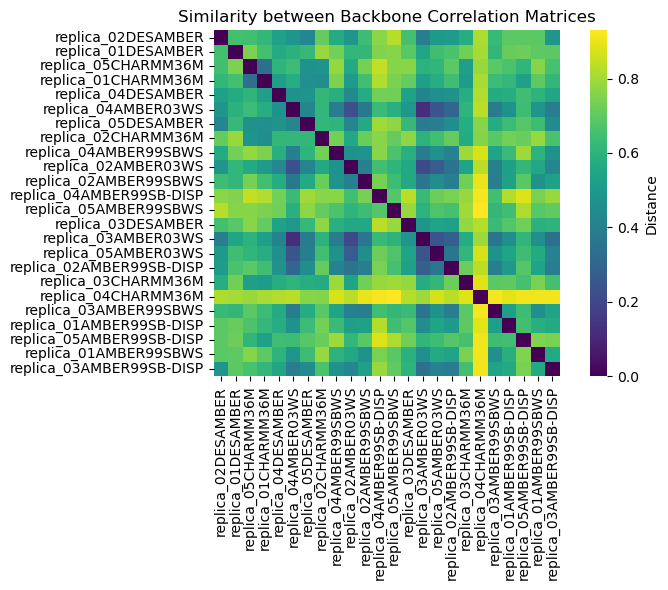

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(dist_square, xticklabels=labels, yticklabels=labels, 
            cmap="viridis", annot=False, square=True, cbar_kws={"label": "Distance"})
plt.title("Similarity between Backbone Correlation Matrices")
plt.tight_layout()
plt.show()


The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix


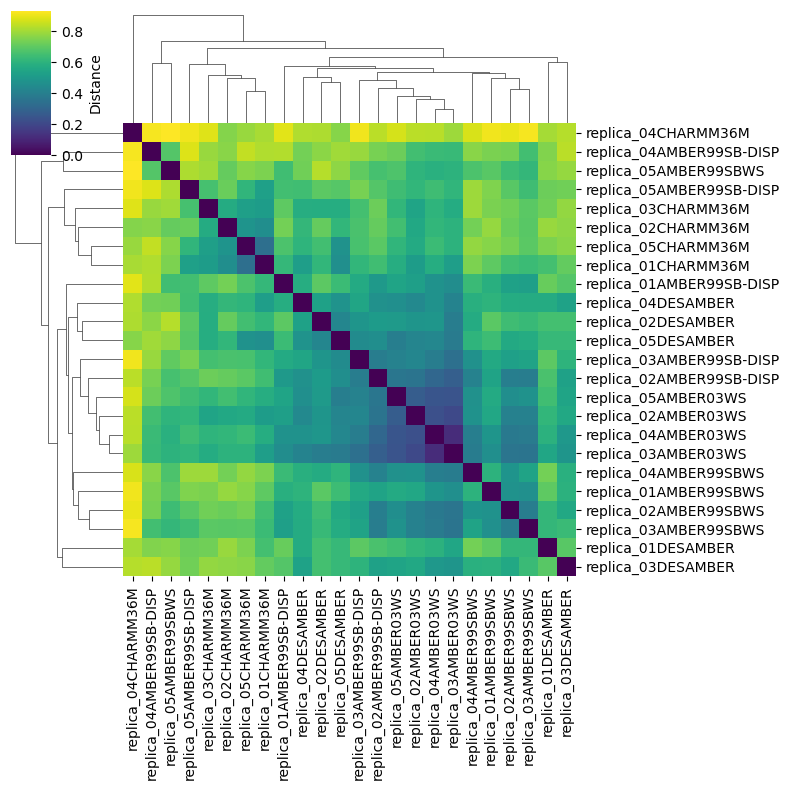

In [35]:
sns.clustermap(dist_square, row_cluster=True, col_cluster=True,
               xticklabels=labels, yticklabels=labels,
               cmap="viridis", figsize=(8,8),
               cbar_kws={"label": "Distance"})


In [17]:
features_relax = []
for system in systems:
    relax_file = '../../Data/Simulations/' + system['path'] + 'spin_relaxation_times.yaml'
    with open(relax_file) as f:
        relax = yaml.safe_load(f)
    
    records = []
    for resid, fields in relax.items():
        for field, values in fields.items():
            if field == 600:   # only 600 MHz, for example
                row = {'Residue': resid}
                for param, entry in values.items():
                    row[param] = entry['value']
                records.append(row)
    df = pd.DataFrame(records).set_index('Residue').fillna(0.0)
    features_relax.append(df.to_numpy().flatten())


KeyError: "None of ['Residue'] are in the columns"

In [18]:
import yaml
import pandas as pd

features_relax = []

for system in systems:
    relax_file = '../../Data/Simulations/' + system['path'] + 'spin_relaxation_times.yaml'
    with open(relax_file) as f:
        relax = yaml.safe_load(f)

    records = []
    for resid, fields in relax.items():
        for field, values in fields.items():
            # convert field to string so we don’t mismatch
            field_str = str(field)
            if field_str == "600":   # only 600 MHz, for example
                row = {"Residue": resid}
                for param, entry in values.items():
                    row[param] = entry["value"]
                records.append(row)

    if not records:
        print(f"⚠️ No 600 MHz data found for {system['ID']} — check field names in YAML.")
        continue

    df = pd.DataFrame(records).set_index("Residue").fillna(0.0)
    features_relax.append(df.to_numpy().flatten())


⚠️ No 600 MHz data found for 51 — check field names in YAML.


In [19]:
features_relax

[array([ 0.56409486,  0.19069878,  0.21535232,  0.58879677,  0.21415029,
         0.07899975,  0.60209027,  0.26133967,  0.05433507,  0.76767115,
         0.37436225, -0.16600265,  0.61452694,  0.27096744,  0.11461338,
         0.68754647,  0.25925762,  0.07996513,  0.55292149,  0.21946897,
         0.22093598,  0.54831685,  0.22777478,  0.24598763,  0.56932868,
         0.20348375,  0.22225773,  0.59344113,  0.16401618,  0.19086572,
         0.55721358,  0.11281211,  0.29644099,  0.58061713,  0.17560641,
         0.33619518,  0.58295797,  0.11158024,  0.36898436,  0.57433041,
         0.11952263,  0.44301997,  0.59404261,  0.12006802,  0.46567978,
         0.56390477,  0.11582556,  0.4878084 ,  0.56337351,  0.12744035,
         0.46014913,  0.58940501,  0.10664501,  0.44032549,  0.57587505,
         0.10214762,  0.41890361,  0.75016575,  0.25695441, -0.3152702 ,
         0.61943736,  0.11450659,  0.33463281,  0.6087417 ,  0.17611732,
         0.2886479 ,  0.5898835 ,  0.1547577 ,  0.3

In [21]:
features_cs = []
labels = []

for system in systems:
    if system['ID'] in IDs:
        dataFolder = '../../Data/Simulations/' + system['path']
        chemical_shifts_file = dataFolder + 'chemical_shifts_sparta.yaml'
        
        with open(chemical_shifts_file) as f:
            cs = yaml.safe_load(f)
        
        df = pd.DataFrame(cs).T.fillna(0.0)
        features_cs.append(df.to_numpy().flatten())
        labels.append(system['SYSTEM'])


In [22]:
features_cs

[array([174.5979507 ,  58.19780346,  63.19797935,   4.46783544,
          0.        ,   0.        ,   0.        ,   0.        ,
        174.74926649,  53.24131246,  39.27999734,   4.87798468,
          8.58493404, 120.51028914,   0.        ,   0.        ,
        177.2680473 ,  52.35407995,  19.5077002 ,   4.42406662,
          8.33391472, 124.21226183,   0.        ,   0.        ,
        175.69209327,  55.46809793,  32.90606929,   4.55861226,
          8.28187009, 118.90205197,   0.        ,   0.        ,
        172.96391672,  60.65279081,  69.04981146,   4.62211526,
          8.05737708, 116.19687808,   0.        ,   0.        ,
        176.49270753,  62.78897868,  32.25872152,   4.5238008 ,
          0.        ,   0.        ,   0.        ,   0.        ,
        175.76438641,  62.28412592,  32.52799267,   4.22504464,
          8.16695936, 118.51423518,   0.        ,   0.        ,
        174.3149447 ,  54.39723384,  30.26568954,   4.6521026 ,
          8.21921386, 123.31448701,   0.

In [24]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

def make_distance_matrix(features, metric='correlation'):
    X = np.vstack(features)
    return squareform(pdist(X, metric=metric))

# distance matrices
dist_corr  = make_distance_matrix(features)
dist_cs    = make_distance_matrix(features_cs)
dist_relax = make_distance_matrix(features_relax)

def flatten_upper(mat):
    return mat[np.triu_indices_from(mat, k=1)]

vec_corr  = flatten_upper(dist_corr)
vec_cs    = flatten_upper(dist_cs)
vec_relax = flatten_upper(dist_relax)

# correlations
r_cs, p_cs = spearmanr(vec_corr, vec_cs)
r_relax, p_relax = spearmanr(vec_corr, vec_relax)

print(f"Chemical Shifts vs Correlations: r={r_cs:.3f}, p={p_cs:.3e}")
print(f"Relaxation vs Correlations:      r={r_relax:.3f}, p={p_relax:.3e}")


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 207 and the array at index 1 has size 162

In [27]:
import numpy as np
import pandas as pd
import yaml
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------
def flatten_upper(mat):
    """Return the upper triangular part of a matrix as a 1D vector."""
    return mat[np.triu_indices_from(mat, k=1)]

def make_distance_matrix(features, metric='correlation'):
    """Compute pairwise distance matrix from feature vectors."""
    X = np.vstack(features)
    return squareform(pdist(X, metric=metric))

# ----------------------------------------------------------
# Load chemical shifts
# ----------------------------------------------------------
def load_chemical_shifts(systems, IDs):
    all_residues = set()
    cs_data = []

    # Pass 1: collect all residues observed
    for system in systems:
        if system['ID'] not in IDs: 
            continue
        fname = f"../../Data/Simulations/{system['path']}chemical_shifts_sparta.yaml"
        with open(fname) as f:
            cs = yaml.safe_load(f)
        all_residues.update(cs.keys())

    all_residues = sorted(all_residues)

    # Pass 2: align and flatten
    for system in systems:
        if system['ID'] not in IDs: 
            continue
        fname = f"../../Data/Simulations/{system['path']}chemical_shifts_sparta.yaml"
        with open(fname) as f:
            cs = yaml.safe_load(f)

        vec = []
        for resid in all_residues:
            if resid in cs:
                vals = cs[resid]
                for atom in ['C','CA','CB','H','HA','N']:
                    vec.append(vals.get(atom, 0.0))
            else:
                vec.extend([0.0]*6)
        cs_data.append(np.array(vec))

    return cs_data, all_residues

# ----------------------------------------------------------
# Load relaxation times
# ----------------------------------------------------------
def load_relaxation(systems, IDs, field='600'):
    all_residues = set()
    relax_data = []

    # Pass 1: collect all residues
    for system in systems:
        if system['ID'] not in IDs: 
            continue
        fname = f"../../Data/Simulations/{system['path']}spin_relaxation_times.yaml"
        with open(fname) as f:
            relax = yaml.safe_load(f)
        all_residues.update(relax.keys())

    all_residues = sorted(all_residues)

    # Pass 2: align and flatten
    for system in systems:
        if system['ID'] not in IDs: 
            continue
        fname = f"../../Data/Simulations/{system['path']}spin_relaxation_times.yaml"
        with open(fname) as f:
            relax = yaml.safe_load(f)

        vec = []
        for resid in all_residues:
            if resid in relax and str(field) in map(str, relax[resid].keys()):
                # find correct key (string or int)
                values = None
                for k in relax[resid].keys():
                    if str(k) == str(field):
                        values = relax[resid][k]
                        break
                vec.extend([
                    values.get('T1', {}).get('value', 0.0),
                    values.get('T2', {}).get('value', 0.0),
                    values.get('hetNOE', {}).get('value', 0.0)
                ])
            else:
                vec.extend([0.0, 0.0, 0.0])
        relax_data.append(np.array(vec))

    return relax_data, all_residues

# ----------------------------------------------------------
# Main comparison
# ----------------------------------------------------------
def compare_datasets(systems, IDs):
    # correlation matrices (your backbone ones already preloaded as features)
    # Here I assume you have "features" = list of flattened correlation matrices
    dist_corr = make_distance_matrix(features)

    # chemical shifts
    features_cs, res_cs = load_chemical_shifts(systems, IDs)
    dist_cs = make_distance_matrix(features_cs)

    # relaxation times
    features_relax, res_relax = load_relaxation(systems, IDs, field=600)
    dist_relax = make_distance_matrix(features_relax)

    # flatten upper triangle
    vec_corr  = flatten_upper(dist_corr)
    vec_cs    = flatten_upper(dist_cs)
    vec_relax = flatten_upper(dist_relax)

    # correlations
    r_cs, p_cs = spearmanr(vec_corr, vec_cs)
    r_relax, p_relax = spearmanr(vec_corr, vec_relax)

    print(f"Chemical Shifts vs Correlations: r={r_cs:.3f}, p={p_cs:.3e}")
    print(f"Relaxation vs Correlations:      r={r_relax:.3f}, p={p_relax:.3e}")

# ----------------------------------------------------------
# Run
# ----------------------------------------------------------
# compare_datasets(systems, IDs)


In [36]:
IDs= all_IDs
compare_datasets(systems, IDs)

Chemical Shifts vs Correlations: r=0.574, p=1.255e-25
Relaxation vs Correlations:      r=0.378, p=8.731e-11
